# Homework 2: Emergent communication models

This homework assignment is to be completed in groups. It is due on December 18, 2025 (midnight). Please upload *all files you created or modified* to the homework folder of your group in studIP.

Group number:

Names:

*General note: It is permitted to use AI tools for coding. Please refer to the uploaded manual `AI_Tools_Guidelines` for recommended ways how to use AI to advance your studies in a way that supports your learning. That means that you should not be satisfied if an AI tool hands you a working version of your code, but that you should put in effort to understand how exactly the problem is solved. Another note of caution: What might work for large programming languages like Python, does not necessarily work for Stan. Check your code carefully and do NOT blindly trust AI.*

## Introduction
In the past weeks, you learned about classical neural network approaches to modeling language, about Reinforcement learning and how these two can be combined with the aim of modeling communication in the emergent communication modeling framework.
The goal of this homework assignment is to learn to apply these models. You will be working with a Github repository of my own research. Learning how to work with this repository will qualify you for conducting your study project or thesis within this project.
Below, you receive a sample project and are guided through the steps of conducting it. For all steps, it is expected that you comment your code, explain what you are doing and why, and interpret all your outcomes and results. 

## 1) Creating the environment and installing packages (non-graded)
This is a prerequisite for the following tasks and is therefore non-graded. Please let me know if you run into problems with installing everything. Follow the installation guide in the [emergent-abstractions repository](https://github.com/kristinakobrock/emergent-abstractions/tree/main) and validate that you can run the training (with a small number of epochs and dataset). Follow the tutorial in the [Tutorial Github repository](https://github.com/kristinakobrock/tutorial-emergent-abstractions/tree/main) to make yourself familiar with the code.

For the following tasks, you can either work directly with the main repository (recommended) or work with the tutorial code.

## 2) Dataset (18 points)
The goal is to implement a hierarchical dataset that follows the following logic from the paper by Hawkins et al., 2018: [Emerging abstractions](https://escholarship.org/uc/item/81s4d7fv)
<img src="img/hierarchy.png" width="400"/>

It differs from the default dataset because the default dataset includes all combinations of objects without implementing a hierarchy. Consider the following example for the default dataset with 3 attributes and 3 values. Concepts are implemented as tuples of objects and fixed vectors which indicate which attributes are relevant to the concept, e.g. ([[2,1,1],[1,0,1],[1,2,1]],(0,0,1)). Where the fixed vector (0,0,1) indicates that only the third attribute is relevant to the concept. [2,1,1],[1,0,1],[1,2,1] are possible objects that satisfy this constraint. You can think of the objects as being a small red circle, a large blue circle and a large green circle - all belonging to the concept 'circle'. Now, in the default dataset, all combinations of attributes are possible, i.e. the higher-level concept don't need to be circles, but could also be the color dimension or the size dimension by specifying the fixed vector as (1,0,0) or (0,1,0). While this certainly makes a lot of sense for compositional features as the ones used here, natural concepts are structured in taxonomic hierarchies (e.g., dalmatian, dog, animal). The goal here is to implement a hierarchical dataset.

### 2.1) Adapting the dataset (12 points)
Adapt the function `get_fixed_vectors` in `dataset.py` to account for hierarchically structured concepts.
Your solution should work for varying dataset sizes and be neatly integrated with the currently available code. Specify a folder where the results for this experiment should be saved to.

In [18]:
# New get_fixed_vectors function. 
# This is how we impoemented the new function in the emergent-abstraction repo.
# We copied it here to show
def get_fixed_vectors_hierarchical(properties_dim):
    """
    Returns the fixed vectors that respect the Hawkins et al. (2018) hierarchy.
    Fixed vectors are binary strings in which a 1 denotes that the attribute at that position is relevant.
    In a strictly hierarchical taxonomy only suffixes of ones (…, 0, 0, 1, 1, 1) are allowed because every
    additional attribute refines the same branch.
    """
    n_attributes = len(properties_dim)
    if n_attributes == 0:
        return []

    hierarchical_vectors = []
    # Start with the most generic concept (only the last attribute is fixed) and progressively refine it.
    vector = [0] * n_attributes
    for attr_idx in range(n_attributes - 1, -1, -1):
        vector[attr_idx] = 1
        hierarchical_vectors.append(tuple(vector))
    return hierarchical_vectors

In [19]:
# Quick comparison as sanity check

import itertools

# Old version
def get_fixed_vectors_old(properties_dim):
    list_of_dim = [range(0, 2) for _ in properties_dim]
    fixed_vectors = list(itertools.product(*list_of_dim))
    fixed_vectors.pop(0)  # remove (0,0,...,0)
    return fixed_vectors


def demo(n_attributes, n_values=3):
    properties_dim = [n_values] * n_attributes  # values don't matter here, only length
    old = get_fixed_vectors_old(properties_dim)
    new = get_fixed_vectors_hierarchical(properties_dim)

    print(f"\n--- n_attributes={n_attributes} ---")
    print(f"Old: {len(old)} vectors")
    print(old)
    print(f"New: {len(new)} vectors")
    print(new)

for n in [0, 1, 2, 3, 4]:
    demo(n)



--- n_attributes=0 ---
Old: 0 vectors
[]
New: 0 vectors
[]

--- n_attributes=1 ---
Old: 1 vectors
[(1,)]
New: 1 vectors
[(1,)]

--- n_attributes=2 ---
Old: 3 vectors
[(0, 1), (1, 0), (1, 1)]
New: 2 vectors
[(0, 1), (1, 1)]

--- n_attributes=3 ---
Old: 7 vectors
[(0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)]
New: 3 vectors
[(0, 0, 1), (0, 1, 1), (1, 1, 1)]

--- n_attributes=4 ---
Old: 15 vectors
[(0, 0, 0, 1), (0, 0, 1, 0), (0, 0, 1, 1), (0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (0, 1, 1, 1), (1, 0, 0, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 0, 1, 1), (1, 1, 0, 0), (1, 1, 0, 1), (1, 1, 1, 0), (1, 1, 1, 1)]
New: 4 vectors
[(0, 0, 0, 1), (0, 0, 1, 1), (0, 1, 1, 1), (1, 1, 1, 1)]


### 2.2) Creating the datasets (6 points)
Use the script `pickle_ds.py` to construct 3 datasets with the following attribute-value combinations D(attributes, values):
- D(3,4)
- D(4,4)
- D(3,8)

The following commands were used to create the new datasets:
- `python pickle_ds.py --dimensions 4 4 4`
- `python pickle_ds.py --dimensions 4 4 4 4`
- `python pickle_ds.py --dimensions 8 8 8`

In [20]:
# Inspect the newly created datasets
import torch

ds = torch.load('data/dim(3,4)_gs10_sf10.ds', weights_only=False)

print("Attributes:", ds.properties_dim)
print("Total concepts:", len(ds.concepts))
print("Train/Val/Test sizes:", [len(split) for split in ds.dataset])

train_split, val_split, test_split = ds.dataset

sender, labels, receiver = train_split[0]  # or val_split[i], test_split[i]
print(sender.shape, labels.shape, receiver.shape)

print("Label vector:", labels.argmax().item())

Attributes: [4, 4, 4]
Total concepts: 84
Train/Val/Test sizes: [1402, 468, 410]
torch.Size([20, 12]) torch.Size([20]) torch.Size([20, 12])
Label vector: 1


## 3) Model simulations (12 points)
Think about which conditions (i.e., settings) you need to compare to discuss whether the implementation of the hierarchical dataset has any measurable impact on the emerging language. Specify which conditions you will compare and why and state your hypotheses. Simulate five runs for each of the datasets and each of the conditions. For hyperparameters, it is recommended to either stick to hyperparameters that were used before (check publications or default settings) or do a grid search over hyperparameters if you expect different hyperparameters to work better.

We chose hyperparameters based on the config file in the tutorial repo (https://github.com/kristinakobrock/tutorial-emergent-abstractions/blob/main/config.yml)and the default settings. We changed n_epochs so that we saw more convergence.

The script for running the different conditions can be found in `run_hier_dataset_matrix.sh`.

The results can be found in `runs/hier_dataset_matrix`.

We created and uploaded the `runs/hier_dataset_matrix/aggregate_metrics.csv` file with the help of the `hier_dataset_matrix_aggregate.ipynb` notebook.

We run a  2×2×2×2 matrix where we vary only:

- Dataset structure: flat vs hierarchical
- Generalization split: generic vs specific
- Context regime: unshared vs shared/context-aware
- Message cost: no_cost vs length_cost

H1:
- In the hierarchical dataset, meanings are nested. We expect the agents to reuse parts of messages: a generic concept will have a “core” message, and more specific concepts will look like the same core with a small, consistent addition. In the flat dataset, this pattern should be weaker because concepts are not forced into a single refinement chain.

H2:
- Because hierarchy creates a consistent path from generic -> specific, agents can learn a simple rule like “add one refinement to be more specific” or “drop refinements to be more general.” Therefore, hierarchical training should transfer better when the test split requires communicating at a different abstraction level than training. Flat training should generalize less reliably because “becoming more specific” can mean many unrelated attribute combinations.

H3:
- When context already rules out many alternatives, agents don’t need to mention every detail every time. In hierarchical datasets, this should encourage them to stop at the right abstraction level: using the generic “stem” when it’s enough and adding refinements only when the context demands it. As a result, hierarchical languages should show more reuse and fewer distinct messages under shared/context-aware settings than flat languages.

H4:
- With a length penalty, agents are rewarded for sending short messages. In a hierarchy, the most efficient strategy is to use a short message for the generic level and add tiny “extra bits” only when more specificity is needed. So we expect hierarchical+length-cost to produce shorter, more reusable messages than flat+length-cost at similar accuracy.

## 4) Analysis (50 points)

    Although we ran a full 2×2×2×2 = 16 condition grid (dataset × split × context × cost), for the main analysis we keep CONTEXT fixed to shared, which results in an 8-condition matrix (dataset × split × cost). We still look at the results across the three dataset complexities (D(3,4), D(3,8), D(4,4)) because they strongly affect both accuracy and language stability.

    Hypotheses tested here:
    - H2 (generalization across abstraction levels): Hierarchical structure should improve transfer across the repository’s abstraction split (generic vs specific), reflected in test accuracy and information metrics (e.g., NMI).
    - H4 (length-cost compression): Adding a length cost should reduce message length and effective vocabulary usage. If hierarchy supports systematic reuse, hierarchical runs should compress more gracefully (shorter messages without collapsing accuracy/informativeness).


### 4.1) Model performance (10 points)
Assess the model performance for each dataset and condition.


In [49]:
# Load shared-context metrics and helpers.
from pathlib import Path
import re

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch

from utils.analysis_from_interaction import (
    information_scores,
    message_length_per_hierarchy_level,
    effective_vocab_size,
    k_hot_to_attributes,
    retrieve_fixed_vectors,
    trim_tensor,
)

sns.set_theme(style="whitegrid")

def load_interaction(path):
    # Interaction objects require full pickle loading in torch>=2.6.
    return torch.load(path, weights_only=False)

def parse_dimensions(dim_str):
    match = re.match(r"D\((\d+),(\d+)\)", dim_str)
    if not match:
        raise ValueError(f"Unexpected dimensions format: {dim_str}")
    return int(match.group(1)), int(match.group(2))

agg_path = Path("runs/hier_dataset_matrix/aggregate_metrics.csv")
metrics_df = pd.read_csv(agg_path)

shared_df = metrics_df[metrics_df["context"] == "shared"].copy()
shared_df[["n_attributes", "n_values"]] = shared_df["dimensions"].apply(
    lambda s: pd.Series(parse_dimensions(s))
)

shared_df["cost"] = pd.Categorical(
    shared_df["cost"], categories=["no_cost", "length_cost"], ordered=True
)
shared_df["split"] = pd.Categorical(
    shared_df["split"], categories=["generic", "specific"], ordered=True
)
shared_df["dataset"] = pd.Categorical(
    shared_df["dataset"], categories=["flat", "hierarchical"], ordered=True
)

shared_df


,dataset,split,context,cost,seed,dimensions,final_test_acc,final_test_loss,avg_message_length,final_message_length,result_path,n_attributes,n_values
0,flat,generic,shared,length_cost,0,"D(3,4)",0.958333,0.144966,3.853977,4.000000,/home/laura/Documents/Uni/Communication and Ab...,3,4
1,flat,generic,shared,length_cost,0,"D(3,8)",0.507292,0.696186,1.000000,1.000000,/home/laura/Documents/Uni/Communication and Ab...,3,8
2,flat,generic,shared,length_cost,0,"D(4,4)",0.505625,0.696358,1.000000,1.000000,/home/laura/Documents/Uni/Communication and Ab...,4,4
3,flat,generic,shared,length_cost,1,"D(3,4)",0.989583,0.043729,3.859759,4.000000,/home/laura/Documents/Uni/Communication and Ab...,3,4
4,flat,generic,shared,length_cost,1,"D(3,8)",0.493750,0.696225,1.000000,1.000000,/home/laura/Documents/Uni/Communication and Ab...,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,hierarchical,specific,shared,no_cost,3,"D(3,8)",0.915921,0.259729,3.921281,4.000000,/home/laura/Documents/Uni/Communication and Ab...,3,8
206,hierarchical,specific,shared,no_cost,3,"D(4,4)",0.958930,0.182326,4.311544,4.582721,/home/laura/Documents/Uni/Communication and Ab...,4,4
207,hierarchical,specific,shared,no_cost,4,"D(3,4)",0.923151,0.275308,3.895625,4.000000,/home/laura/Documents/Uni/Communication and Ab...,3,4
208,hierarchical,specific,shared,no_cost,4,"D(3,8)",0.920817,0.283583,3.969906,4.000000,/home/laura/Documents/Uni/Communication and Ab...,3,8


In [50]:
# Aggregate performance per condition.
perf_summary = (
    shared_df.groupby(["dimensions", "dataset", "split", "cost"], observed=False)
    .agg(
        mean_acc=("final_test_acc", "mean"),
        std_acc=("final_test_acc", "std"),
        mean_loss=("final_test_loss", "mean"),
        std_loss=("final_test_loss", "std"),
        mean_msg_len=("avg_message_length", "mean"),
        std_msg_len=("avg_message_length", "std"),
    )
    .reset_index()
)

display(perf_summary)


,dimensions,dataset,split,cost,mean_acc,std_acc,mean_loss,std_loss,mean_msg_len,std_msg_len
0,"D(3,4)",flat,generic,no_cost,0.989000,0.011260,0.041014,0.041153,3.981457,0.010449
1,"D(3,4)",flat,generic,length_cost,0.972865,0.018718,0.130119,0.078583,3.732767,0.237247
2,"D(3,4)",flat,specific,no_cost,0.982792,0.007259,0.069395,0.038379,3.907070,0.052070
3,"D(3,4)",flat,specific,length_cost,0.782871,0.259131,0.343062,0.324606,2.334633,1.258318
4,"D(3,4)",hierarchical,generic,no_cost,0.971750,0.023875,0.092147,0.108875,3.974728,0.020759
5,"D(3,4)",hierarchical,generic,length_cost,0.874906,0.204154,0.276068,0.318803,3.224871,1.255356
6,"D(3,4)",hierarchical,specific,no_cost,0.919240,0.024940,0.317180,0.055126,3.849594,0.074340
7,"D(3,4)",hierarchical,specific,length_cost,0.903847,0.024449,0.311512,0.052354,2.853281,0.452194
8,"D(3,8)",flat,generic,no_cost,0.979125,0.014468,0.113295,0.076358,4.000000,0.000000
9,"D(3,8)",flat,generic,length_cost,0.503458,0.006179,0.696084,0.000348,1.000000,0.000000


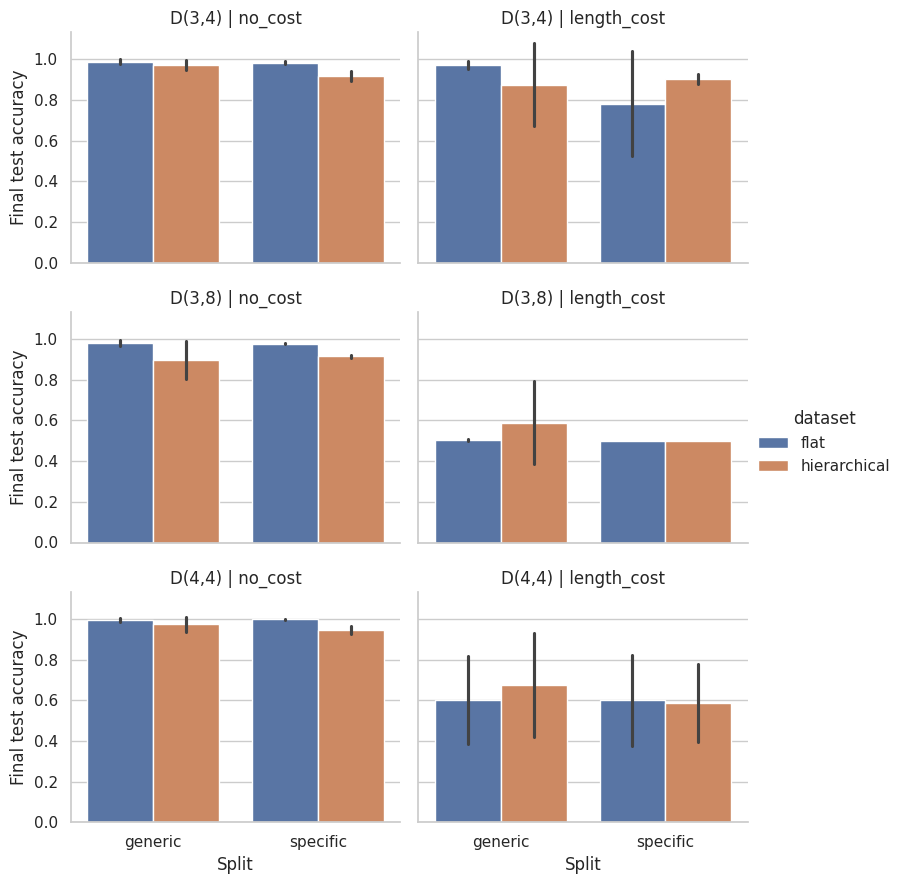

In [51]:
# Plot accuracy by split, dataset, and cost.
g = sns.catplot(
    data=shared_df,
    x="split",
    y="final_test_acc",
    hue="dataset",
    col="cost",
    row="dimensions",
    kind="bar",
    errorbar="sd",
    height=3,
    aspect=1.3,
)
g.set_axis_labels("Split", "Final test accuracy")
g.set_titles("{row_name} | {col_name}")
plt.show()


**Performance (shared context)**

Across dimensions, the dominant factor affecting accuracy is message-length cost:

- No-cost runs are near-ceiling in most settings (especially D(3,4)), indicating that the agents can solve the referential task when they are not penalized for longer messages.
- Under length cost, performance becomes dimension-dependent. In our results, the harder settings (notably D(3,8) and D(4,4)) often show large accuracy drops toward chance. This suggests that the pressure to be short overwhelms the pressure to be informative.

The effect of hierarchy on accuracy is present but not uniform:
- In some settings, hierarchy helps (e.g., it can improve stability or generalization for one split).
- In other settings, hierarchy slightly hurts or shows high variance across seeds.

### 4.2) Quantitative analysis (25 points)
Analyze the emerging languages in your conditions with metrics as you see fit. You can check out the emergent-abstractions github repository for inspiration. Your analysis should at least include the following metrics:
- NMI
- message length

Choose two additional metrics or types of quantitative analysis and interpret all your results.

    In addition to accuracy, we analyze the emergent languages using interaction-based metrics computed from saved test interactions.

**Required metrics**
- Message length: average number of symbols/tokens per message. This directly reflects compression pressure and is cimportant for testing H4.
- NMI (Normalized Mutual Information): measures how strongly messages align with meanings (concept labels).  
  - High NMI: messages are informative about meanings (less arbitrary / less ambiguous).
  - Low NMI: messages carry little information about meanings (e.g., collapse or heavy synonymy/ambiguity).

**Two additional metrics (chosen here)**
- Effectiveness: how much information the message conveys about the target meaning in context (higher is better).  
- Effective vocabulary ratio: how many distinct messages are actually used relative to the theoretical vocabulary size (lower often means more reuse/compression, but can also reflect collapse).


In [52]:
# Compute interaction-based language metrics (NMI, vocab, length).
def get_interaction_path(result_path, split="validation", epoch=100):
    return (
        Path(result_path)
        / "interactions"
        / split
        / f"epoch_{epoch}"
        / "interaction_gpu0"
    )

metrics_rows = []
missing_interactions = []

for row in shared_df.itertuples(index=False):
    interaction_path = get_interaction_path(row.result_path)
    if not interaction_path.exists():
        missing_interactions.append(str(interaction_path))
        continue
    interaction = load_interaction(interaction_path)
    vocab_size = interaction.message.size(-1)
    scores = information_scores(interaction, row.n_attributes, row.n_values)
    eff_vocab_size, _, eff_vocab_ratio = effective_vocab_size(interaction, vocab_size)
    msg_len, msg_len_levels = message_length_per_hierarchy_level(interaction, row.n_attributes)
    row_dict = {
        "dimensions": row.dimensions,
        "dataset": row.dataset,
        "split": row.split,
        "cost": row.cost,
        "seed": row.seed,
        "nmi": float(scores["normalized_mutual_info"]),
        "effectiveness": float(scores["effectiveness"]),
        "consistency": float(scores["consistency"]),
        "eff_vocab_size": int(eff_vocab_size),
        "eff_vocab_ratio": float(eff_vocab_ratio),
        "avg_msg_len": float(msg_len.float().mean().item()),
    }
    for i, lvl in enumerate(msg_len_levels, start=1):
        row_dict[f"msg_len_level_{i}"] = lvl
    metrics_rows.append(row_dict)

metrics_interaction_df = pd.DataFrame(metrics_rows)
print("Computed interaction metrics for", len(metrics_interaction_df), "runs")
if missing_interactions:
    print("Missing interactions (first 3):")
    print("\n".join(missing_interactions[:3]))


/home/laura/Documents/Uni/Communication and Abstraction/emergent-abstractions-HW2/utils/analysis_from_interaction.py:354: RuntimeWarning: invalid value encountered in divide
  normalized_MI_hierarchical = ((m_entropy_hierarchical + c_entropy_hierarchical - joint_entropy_hierarchical)
/home/laura/Documents/Uni/Communication and Abstraction/emergent-abstractions-HW2/utils/analysis_from_interaction.py:360: RuntimeWarning: invalid value encountered in divide
  (m_entropy_concept_x_context + c_entropy_concept_x_context - joint_entropy_concept_x_context)
/home/laura/Documents/Uni/Communication and Abstraction/emergent-abstractions-HW2/utils/analysis_from_interaction.py:365: RuntimeWarning: invalid value encountered in divide
  normalized_effectiveness_hierarchical = ((joint_entropy_hierarchical - m_entropy_hierarchical)
/home/laura/Documents/Uni/Communication and Abstraction/emergent-abstractions-HW2/utils/analysis_from_interaction.py:369: RuntimeWarning: invalid value encountered in divide


Computed interaction metrics for 120 runs


In [54]:
# Merge aggregate metrics with interaction metrics.
analysis_df = shared_df.merge(
    metrics_interaction_df,
    on=["dimensions", "dataset", "split", "cost", "seed"],
    how="left",
)

analysis_df

,dataset,split,context,cost,seed,dimensions,final_test_acc,final_test_loss,avg_message_length,final_message_length,...,nmi,effectiveness,consistency,eff_vocab_size,eff_vocab_ratio,avg_msg_len,msg_len_level_1,msg_len_level_2,msg_len_level_3,msg_len_level_4
0,flat,generic,shared,length_cost,0,"D(3,4)",0.958333,0.144966,3.853977,4.000000,...,0.522761,0.410093,0.720790,9,0.562500,3.000000,NaN,3.000,3.000,NaN
1,flat,generic,shared,length_cost,0,"D(3,8)",0.507292,0.696186,1.000000,1.000000,...,0.000000,0.000000,NaN,1,0.035714,0.000000,NaN,0.000,0.000,NaN
2,flat,generic,shared,length_cost,0,"D(4,4)",0.505625,0.696358,1.000000,1.000000,...,0.000000,0.000000,NaN,1,0.062500,0.000000,NaN,0.000,0.000,0.0
3,flat,generic,shared,length_cost,1,"D(3,4)",0.989583,0.043729,3.859759,4.000000,...,0.572130,0.468472,0.734694,13,0.812500,3.000000,NaN,3.000,3.000,NaN
4,flat,generic,shared,length_cost,1,"D(3,8)",0.493750,0.696225,1.000000,1.000000,...,0.000000,0.000000,NaN,1,0.035714,0.000000,NaN,0.000,0.000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,hierarchical,specific,shared,no_cost,3,"D(3,8)",0.915921,0.259729,3.921281,4.000000,...,0.674315,0.574816,0.815470,15,0.535714,3.000000,3.0,3.000,NaN,NaN
116,hierarchical,specific,shared,no_cost,3,"D(4,4)",0.958930,0.182326,4.311544,4.582721,...,0.575644,0.481606,0.715316,12,0.750000,3.582721,2.8,3.293,3.653,NaN
117,hierarchical,specific,shared,no_cost,4,"D(3,4)",0.923151,0.275308,3.895625,4.000000,...,0.685124,0.603754,0.791843,10,0.625000,3.000000,3.0,3.000,NaN,NaN
118,hierarchical,specific,shared,no_cost,4,"D(3,8)",0.920817,0.283583,3.969906,4.000000,...,0.663696,0.553338,0.829041,13,0.464286,3.000000,3.0,3.000,NaN,NaN


In [55]:
# Summarize language metrics per condition.
metric_summary = (
    analysis_df.groupby(["dimensions", "dataset", "split", "cost"])
    .agg(
        nmi_mean=("nmi", "mean"),
        nmi_std=("nmi", "std"),
        eff_mean=("effectiveness", "mean"),
        eff_std=("effectiveness", "std"),
        cons_mean=("consistency", "mean"),
        cons_std=("consistency", "std"),
        avg_msg_len_mean=("avg_msg_len", "mean"),
        avg_msg_len_std=("avg_msg_len", "std"),
        eff_vocab_ratio_mean=("eff_vocab_ratio", "mean"),
        eff_vocab_ratio_std=("eff_vocab_ratio", "std"),
    )
    .reset_index()
)

display(metric_summary)


,dimensions,dataset,split,cost,nmi_mean,nmi_std,eff_mean,eff_std,cons_mean,cons_std,avg_msg_len_mean,avg_msg_len_std,eff_vocab_ratio_mean,eff_vocab_ratio_std
0,"D(3,4)",flat,generic,length_cost,0.553454,0.019788,0.451305,0.025633,0.716669,0.011807,2.809091,0.426886,0.725000,0.129603
1,"D(3,4)",flat,generic,no_cost,0.549129,0.011511,0.448771,0.016426,0.707877,0.004310,3.000000,0.000000,0.775000,0.071261
2,"D(3,4)",flat,specific,length_cost,0.378642,0.345725,0.311365,0.284278,0.805052,0.017407,1.626562,1.497650,0.350000,0.270994
3,"D(3,4)",flat,specific,no_cost,0.640199,0.008251,0.531933,0.003114,0.804265,0.026414,3.000000,0.000000,0.687500,0.076547
4,"D(3,4)",hierarchical,generic,length_cost,0.453363,0.254750,0.375085,0.212576,0.718539,0.002941,2.344118,1.315975,0.625000,0.318689
5,"D(3,4)",hierarchical,generic,no_cost,0.549517,0.018862,0.447979,0.027102,0.712699,0.021181,3.000000,0.000000,0.800000,0.052291
6,"D(3,4)",hierarchical,specific,length_cost,0.690170,0.030335,0.612552,0.039440,0.791774,0.029937,2.578125,0.401869,0.512500,0.081490
7,"D(3,4)",hierarchical,specific,no_cost,0.687210,0.032641,0.611748,0.045783,0.786318,0.032377,3.000000,0.000000,0.587500,0.034233
8,"D(3,8)",flat,generic,length_cost,0.000000,0.000000,0.000000,0.000000,NaN,NaN,0.000000,0.000000,0.035714,0.000000
9,"D(3,8)",flat,generic,no_cost,0.566994,0.019208,0.450249,0.025073,0.766921,0.006219,3.000000,0.000000,0.864286,0.099103


Plot: NMI by split (shared context)


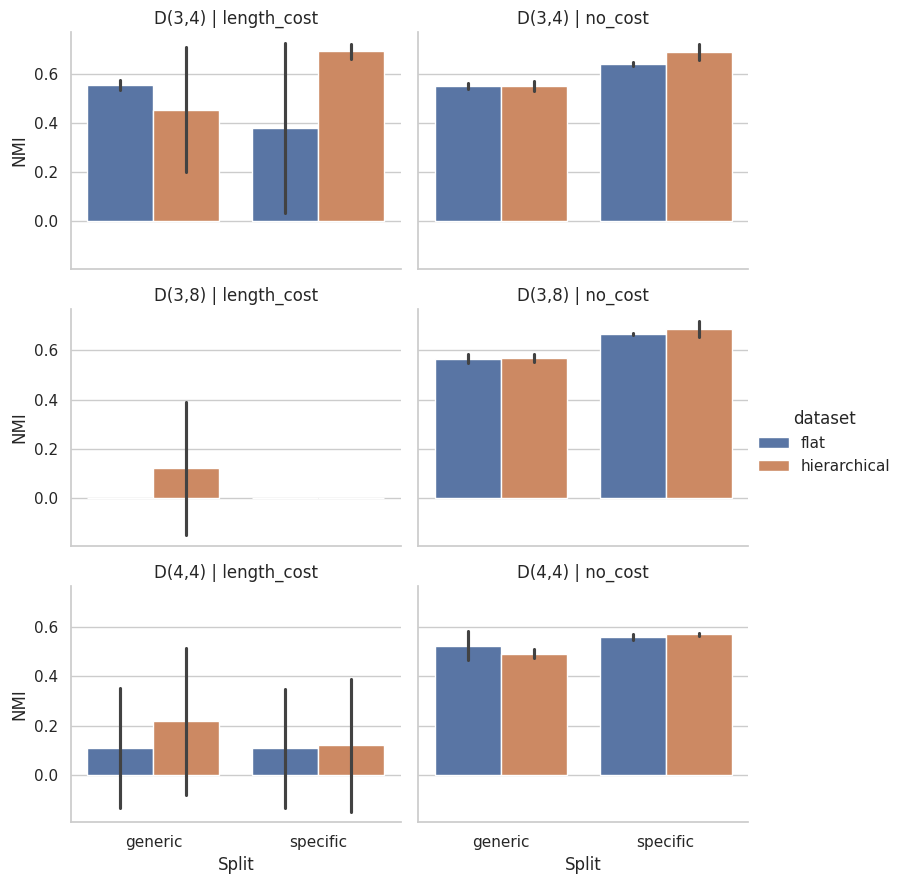

Plot: Average message length by cost (shared context)


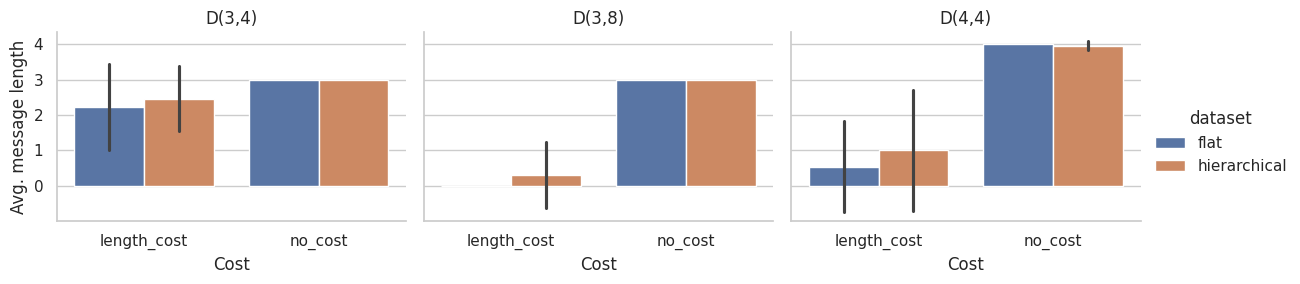

Plot: Effective vocab ratio by cost (shared context)


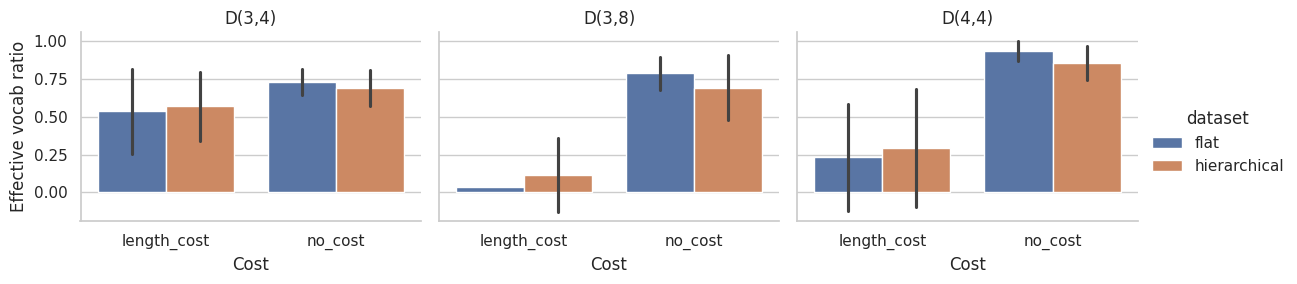

In [59]:
# Plot NMI, message length, and vocab usage.
print("Plot: NMI by split (shared context)")
g = sns.catplot(
    data=analysis_df,
    x="split",
    y="nmi",
    hue="dataset",
    col="cost",
    row="dimensions",
    kind="bar",
    errorbar="sd",
    height=3,
    aspect=1.3,
)
g.set_axis_labels("Split", "NMI")
g.set_titles("{row_name} | {col_name}")
plt.show()

print("Plot: Average message length by cost (shared context)")

g = sns.catplot(
    data=analysis_df,
    x="cost",
    y="avg_msg_len",
    hue="dataset",
    col="dimensions",
    kind="bar",
    errorbar="sd",
    height=3,
    aspect=1.3,
)
g.set_axis_labels("Cost", "Avg. message length")
g.set_titles("{col_name}")
plt.show()

print("Plot: Effective vocab ratio by cost (shared context)")

g = sns.catplot(
    data=analysis_df,
    x="cost",
    y="eff_vocab_ratio",
    hue="dataset",
    col="dimensions",
    kind="bar",
    errorbar="sd",
    height=3,
    aspect=1.3,
)
g.set_axis_labels("Cost", "Effective vocab ratio")
g.set_titles("{col_name}")
plt.show()


In [57]:
# H2/H4 tables: split gap and length-cost effect.

h2_nmi = metric_summary.pivot_table(
    index=["dimensions", "dataset", "cost"],
    columns="split",
    values="nmi_mean",
)
h2_nmi["specific_minus_generic"] = h2_nmi["specific"] - h2_nmi["generic"]
print("H2: NMI by split (specific vs generic)")
display(h2_nmi)

h4_len = metric_summary.pivot_table(
    index=["dimensions", "dataset", "split"],
    columns="cost",
    values="avg_msg_len_mean",
)
h4_len["length_cost_minus_no_cost"] = h4_len["length_cost"] - h4_len["no_cost"]
print("H4: Message length change (length_cost - no_cost)")
display(h4_len)

h4_vocab = metric_summary.pivot_table(
    index=["dimensions", "dataset", "split"],
    columns="cost",
    values="eff_vocab_ratio_mean",
)
h4_vocab["length_cost_minus_no_cost"] = h4_vocab["length_cost"] - h4_vocab["no_cost"]
print("H4: Effective vocab ratio change (length_cost - no_cost)")
display(h4_vocab)


H2: NMI by split (specific vs generic)


split                                 generic  specific  \
dimensions dataset      cost                              
D(3,4)     flat         length_cost  0.553454  0.378642   
                        no_cost      0.549129  0.640199   
           hierarchical length_cost  0.453363  0.690170   
                        no_cost      0.549517  0.687210   
D(3,8)     flat         length_cost  0.000000  0.000000   
                        no_cost      0.566994  0.666813   
           hierarchical length_cost  0.120313  0.000000   
                        no_cost      0.567982  0.687110   
D(4,4)     flat         length_cost  0.109497  0.108159   
                        no_cost      0.525003  0.559432   
           hierarchical length_cost  0.216951  0.120721   
                        no_cost      0.491518  0.571025   

split                                specific_minus_generic  
dimensions dataset      cost                                 
D(3,4)     flat         length_cost               -0.174812  
                        no_cost                    0.091070  
           hierarchical length_cost                0.236807  
                        no_cost                    0.137693  
D(3,8)     flat         length_cost                0.000000  
                        no_cost                    0.099819  
           hierarchical length_cost               -0.120313  
                        no_cost                    0.119128  
D(4,4)     flat         length_cost               -0.001338  
                        no_cost                    0.034429  
           hierarchical length_cost               -0.096230  
                        no_cost                    0.079507

H4: Message length change (length_cost - no_cost)


cost                              length_cost   no_cost  \
dimensions dataset      split                             
D(3,4)     flat         generic      2.809091  3.000000   
                        specific     1.626562  3.000000   
           hierarchical generic      2.344118  3.000000   
                        specific     2.578125  3.000000   
D(3,8)     flat         generic      0.000000  3.000000   
                        specific     0.000000  3.000000   
           hierarchical generic      0.590048  3.000000   
                        specific     0.000000  3.000000   
D(4,4)     flat         generic      0.800000  4.000000   
                        specific     0.283059  4.000000   
           hierarchical generic      1.202642  4.000000   
                        specific     0.800000  3.916544   

cost                              length_cost_minus_no_cost  
dimensions dataset      split                                
D(3,4)     flat         generic                   -0.190909  
                        specific                  -1.373438  
           hierarchical generic                   -0.655882  
                        specific                  -0.421875  
D(3,8)     flat         generic                   -3.000000  
                        specific                  -3.000000  
           hierarchical generic                   -2.409952  
                        specific                  -3.000000  
D(4,4)     flat         generic                   -3.200000  
                        specific                  -3.716941  
           hierarchical generic                   -2.797358  
                        specific                  -3.116544

H4: Effective vocab ratio change (length_cost - no_cost)


cost                              length_cost   no_cost  \
dimensions dataset      split                             
D(3,4)     flat         generic      0.725000  0.775000   
                        specific     0.350000  0.687500   
           hierarchical generic      0.625000  0.800000   
                        specific     0.512500  0.587500   
D(3,8)     flat         generic      0.035714  0.864286   
                        specific     0.035714  0.714286   
           hierarchical generic      0.192857  0.892857   
                        specific     0.035714  0.492857   
D(4,4)     flat         generic      0.237500  0.975000   
                        specific     0.225000  0.900000   
           hierarchical generic      0.425000  0.950000   
                        specific     0.162500  0.762500   

cost                              length_cost_minus_no_cost  
dimensions dataset      split                                
D(3,4)     flat         generic                   -0.050000  
                        specific                  -0.337500  
           hierarchical generic                   -0.175000  
                        specific                  -0.075000  
D(3,8)     flat         generic                   -0.828571  
                        specific                  -0.678571  
           hierarchical generic                   -0.700000  
                        specific                  -0.457143  
D(4,4)     flat         generic                   -0.737500  
                        specific                  -0.675000  
           hierarchical generic                   -0.525000  
                        specific                  -0.600000

**Quantitative interpretation (H2 & H4; using NMI, message length, effectiveness, and effective vocab ratio)**

**H4 (length-cost compression)**

Across dimensions, adding length cost consistently reduces message length and shrinks the effective vocabulary ratio, but whether this is "good compression" or "collapse" depends on complexity:

- **D(3,4): mostly "good compression" for some conditions, but not all**
  - Flat-generic shows only a small length drop (3 -> 2.81) and keeps NMI roughly stable (~0.55), so compression is mild and communication remains informative.
  - Flat-specific shows a large length drop (3 -> 1.63) and NMI drops sharply (~0.64 -> ~0.38), matching the accuracy instability. This looks like partial collapse under compression.
  - Hierarchical-specific is the clearest "good compression" case: length decreases (3 -> 2.58) while NMI stays high (~0.69) and accuracy stays high (~0.90). This suggests hierarchy supports shorter but still systematic messages in this regime.

- **D(3,8): length cost frequently produces collapse**
  - Many length-cost conditions have NMI = 0 and near-zero message lengths, indicating degenerate language (immediate EOS / uninformative codes). Hierarchical-generic is the only partial exception (small but non-zero NMI/length), but still far below no-cost performance.

- **D(4,4): length cost leads to strong degradation rather than clean compression**
  - Message length collapses from 4 to < 1 in most conditions and NMI drops to ~0.11-0.22. Hierarchical-generic retains somewhat higher NMI and longer messages than flat-generic, but the overall regime still looks compression-dominated.

**Takeaway for H4:** Length cost reliably enforces shorter messages, but in the harder settings it often pushes the system into an uninformative regime. Hierarchy can mitigate collapse in some cases (notably D(3,4) specific), but does not prevent it across all complexities.


**H2 (generic vs specific split):**

To test H2, we use the table `h2_nmi` (specific minus generic) alongside accuracy:

- In D(3,4), the split effect depends on dataset structure:
  - Flat + length-cost: specific NMI is lower than generic (negative gap), consistent with weaker/inconsistent language and the large accuracy variance in that condition.
  - Hierarchical + length-cost: specific NMI is higher than generic (positive gap), and specific accuracy remains high. This suggests hierarchy helps maintain informative messages for specific concepts under compression.

- In D(3,8) under length cost, both splits often collapse (NMI = 0), so the split gap becomes uninformative: when the language collapses, it cannot express either level well.

- In D(4,4), no-cost runs show specific > generic NMI (positive gap), but under length cost both splits degrade heavily; hierarchy changes the magnitude slightly but not the qualitative outcome.

**Takeaway for H2:** Hierarchy does not guarantee better generalization everywhere, but it clearly changes the split behavior in the most interpretable regime (D(3,4) under length cost), where it stabilizes specific-level informativeness relative to the flat dataset.


### 4.3) Qualitative analysis (15 points)
Look at the emerging messages and concepts from the interaction files (see tutorial). Assess the differences between simulations with and without the hierarchical datasets. Can you make out specific test cases where the results (should) differ? Come up with a good way to visualize your results, either as a tidy table, or a visual representation, for example with clustering methods.

,target,fixed_vector,level,message,dataset
7,"[1.0, 2.0, 3.0]","[0.0, 1.0, 0.0]",1,"[8, 8, 8]",flat
10,"[0.0, 1.0, 1.0]","[0.0, 0.0, 1.0]",1,"[2, 14, 14]",flat
0,"[1.0, 1.0, 0.0]","[1.0, 1.0, 0.0]",2,"[8, 9, 9]",flat
1,"[3.0, 1.0, 2.0]","[1.0, 0.0, 1.0]",2,"[9, 9, 9]",flat
2,"[1.0, 0.0, 2.0]","[1.0, 0.0, 1.0]",2,"[8, 9, 9]",flat
3,"[3.0, 2.0, 1.0]","[0.0, 1.0, 1.0]",2,"[8, 8, 8]",flat
4,"[2.0, 3.0, 0.0]","[1.0, 0.0, 1.0]",2,"[2, 2, 2]",flat
5,"[3.0, 3.0, 2.0]","[0.0, 1.0, 1.0]",2,"[12, 12, 12]",flat
6,"[0.0, 1.0, 2.0]","[1.0, 0.0, 1.0]",2,"[9, 9, 9]",flat
8,"[2.0, 3.0, 3.0]","[0.0, 1.0, 1.0]",2,"[12, 12, 12]",flat


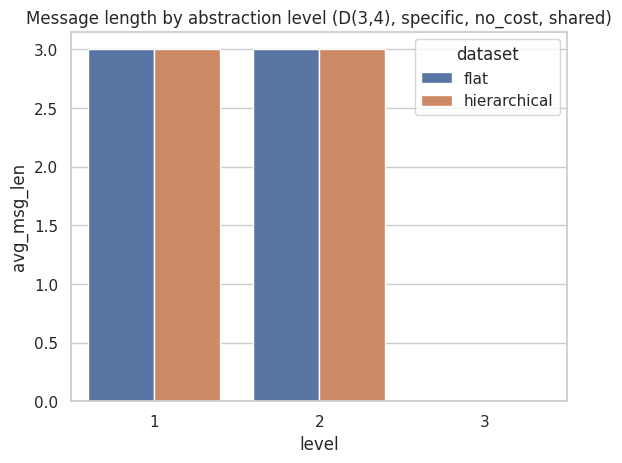

In [67]:
# Qualitative samples and per-level message length.
def select_run_path(dimensions, dataset, split, cost, seed=0):
    row = shared_df[
        (shared_df["dimensions"] == dimensions)
        & (shared_df["dataset"] == dataset)
        & (shared_df["split"] == split)
        & (shared_df["cost"] == cost)
        & (shared_df["seed"] == seed)
    ].iloc[0]
    return row["result_path"], int(row["n_values"]), int(row["n_attributes"])

def sample_messages_from_run(result_path, n_values, n_samples=12, seed=0):
    interaction = load_interaction(get_interaction_path(result_path))
    sender_input = interaction.sender_input.detach().cpu().numpy()
    n_objects = sender_input.shape[1]
    n_targets = n_objects // 2
    targets = sender_input[:, :n_targets]
    targets = k_hot_to_attributes(targets, n_values)
    fixed_vectors = retrieve_fixed_vectors(targets)

    messages = interaction.message.argmax(dim=-1)
    rng = np.random.default_rng(seed)
    idxs = rng.choice(len(messages), size=min(n_samples, len(messages)), replace=False)

    rows = []
    for idx in idxs:
        msg_trim = trim_tensor(messages[idx]).tolist()
        rows.append({
            "target": targets[idx][0].tolist(),
            "fixed_vector": fixed_vectors[idx].tolist(),
            "level": int(np.sum(fixed_vectors[idx])),
            "message": msg_trim,
        })
    return pd.DataFrame(rows)

qual_dim = "D(3,4)"
qual_split = "specific"
qual_cost = "no_cost"
qual_seed = 0

flat_path, n_values, n_attributes = select_run_path(
    qual_dim, "flat", qual_split, qual_cost, qual_seed
)
hier_path, _, _ = select_run_path(
    qual_dim, "hierarchical", qual_split, qual_cost, qual_seed
)

flat_samples = sample_messages_from_run(flat_path, n_values, n_samples=12, seed=0)
flat_samples["dataset"] = "flat"
hier_samples = sample_messages_from_run(hier_path, n_values, n_samples=12, seed=0)
hier_samples["dataset"] = "hierarchical"

samples_df = pd.concat([flat_samples, hier_samples], ignore_index=True)
display(samples_df.sort_values(["dataset", "level"]))

flat_interaction = load_interaction(get_interaction_path(flat_path))
hier_interaction = load_interaction(get_interaction_path(hier_path))
_, flat_levels = message_length_per_hierarchy_level(flat_interaction, n_attributes)
_, hier_levels = message_length_per_hierarchy_level(hier_interaction, n_attributes)

levels_df = pd.DataFrame({
    "level": list(range(1, n_attributes + 1)) * 2,
    "avg_msg_len": flat_levels + hier_levels,
    "dataset": ["flat"] * n_attributes + ["hierarchical"] * n_attributes,
})

sns.barplot(data=levels_df, x="level", y="avg_msg_len", hue="dataset")
plt.title(f"Message length by abstraction level ({qual_dim}, {qual_split}, {qual_cost}, shared)")
plt.show()



**Qualitative analysis: message length by abstraction level**

Across the plots, within a given condition the average message length is essentially flat across levels (no clear monotonic increase from generic to specific). Instead, message length is driven primarily by training regime (length_cost vs no_cost) and by whether the run enters a collapse regime.

**D(3,4), specific, shared:**  
- Under no_cost, both datasets saturate at the maximum length (3 tokens) for all observed levels. This is expected: without a penalty, the agents have no incentive to shorten messages, so length becomes uninformative about abstraction.
- Under length_cost, both datasets shorten messages, but the hierarchical dataset stays systematically longer than the flat dataset (3 vs 2.7), suggesting that in this setting the hierarchical agents preserve more information under compression (consistent with the higher stability/NMI patterns reported in the quantitative section).

**D(4,4), specific, shared, length_cost:**  
This plot is the clearest qualitative signature of "collapse vs non-collapse." The flat dataset effectively collapses to empty messages (avg length 0, so its bars are absent), while the hierarchical dataset produces max-length messages (4) consistently. This implies that, at least for this seed/condition, the hierarchical structure prevents the trivial EOS-only solution that the flat agents fall into under strong pressure.


**Qualitative analysis: message samples**

**D(3,4), specific, length_cost, shared (seed=0):**  
The flat model mostly uses a small set of repeated-token messages like `[13,13,13]`, `[9,9,9]`, `[11,11,11]`, with a few shorter variants such as `[9]` or `[2,2]`. The hierarchical model also uses repeated-token codes (e.g., `[6,6,6]`, `[4,4,4]`, `[11,11,11]`), but the codes appear more consistently full-length in this sample. Importantly, neither dataset shows an obvious "stem + refinement" structure by eye. Messages behave more like compact labels than compositional constructions, which matches the message-length-by-level plots (no systematic length increase with level).

**D(3,4), specific, no_cost, shared (seed=0):**  
Both flat and hierarchical produce almost exclusively length-3 messages, again typically repeated-token patterns. This supports the interpretation that, without a cost, the system does not need to compress or trade off informativeness vs brevity, so qualitative differences between datasets are subtle in surface form.

**D(4,4), specific, length_cost, shared (seed=0):**  
Here the qualitative difference is dramatic: the flat model outputs empty messages `[]` for every sampled concept, i.e., complete degeneration under length pressure. In contrast, the hierarchical model outputs consistent length-4 messages (often repeated-token codes like `[2,2,2,2]`, `[11,11,11,11]`), showing that hierarchical structure can maintain non-trivial signaling in a regime where flat collapses.


## 5) Discussion (20 points)
Summarize your results and discuss whether the hierarchical dataset implementation resulted in measurable differences in the emerging language.

    Across the shared-context 8-condition matrix, model performance is generally high in the no-cost settings, with accuracy near ceiling for most dimensions. Adding length cost consistently reduces average message length and effective vocabulary usage, showing clear pressure to compress messages. This compression sometimes comes with a drop in task performance, especially for larger value sets like D(3,8) and D(4,4). This supports H4: length cost changes communication efficiency by producing shorter messages and smaller effective lexicons, but it can also reduce accuracy and NMI.

    For H2 (generalization across abstraction levels), comparing the generic and specific splits shows that hierarchical datasets can reduce (or sometimes reverse) the NMI gap between splits compared to flat datasets. This suggests that hierarchy can encourage more consistent coding across abstraction levels. However, the effect is not the same in every setting: under strong length pressure, hierarchy can help specific-level generalization in some cases, but it does not always increase overall informativeness (NMI/effectiveness). Overall, hierarchy seems to change how information is organized across levels, but its benefit depends on task difficulty and how strong the compression pressure is.

    Qualitatively, the biggest difference between flat and hierarchical datasets in the runs we inspected is not a clear “stem + refinement” message pattern, but how they behave under strong length cost. In the easier D(3,4) specific setting, both datasets mostly use short, label-like repeated-token messages, and message length stays fairly flat across abstraction levels. In the harder D(4,4) specific length-cost run (seed=0), the flat model collapses to empty messages across the sampled concepts, while the hierarchical model produces consistent full-length messages; the message-length-by-level plot shows this clearly (flat near 0 vs hierarchical near max length). This matches the quantitative results: hierarchy can help keep communication from collapsing in harder settings under strong compression, even if it does not always create visibly compositional messages across levels.

## Bonus task (15 bonus points)
You receive 15 bonus points for trying to replicate the above-mentioned study by [Hawkins et al. (2018)](https://escholarship.org/uc/item/81s4d7fv) with a hierarchical dataset. This can be done in the scope of the assignments above. Suitable parameters for creating datasets with different context granularities are implemented in the main Github repository and can be used for this task. Make sure to present an analysis and discussion linking the simulation results to results from the paper.

## X) Reflection (no points, but mandatory)

Reflect on your group work. What went well? What did not go well?

Please note down the group members' team roles anonymously and reflect on how you filled this role. 


The communication and teamwork started off well, everyone having an idea what parts of the assignment they will mainly focus on.
The first 3 Tasks were completed rather swiftly, whereas Task 4 and 5 proved more difficult. The extension of the deadline was definitely helpful.
The code base of the repo we had to work with felt somewhat disorganised at times, making it harder to get a clear picture of the project. The tutorial notebook was helpful though.

It is hard to say what roles we would identify ourselves, because in this homework we worked more independently, touching base mostly at the beginning and end of the homework, with some minor feedback throughout.